# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiones **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **pruebas estadísticas apropiadas** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [25]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [26]:
# Cargar el dataset.
# El archivo original vive en la plataforma de TripleTen (/datasets/).
# Fuera de esa plataforma se busca en la carpeta local data/.
try:
    df = pd.read_csv('/datasets/landing_experiment.csv')
except FileNotFoundError:
    df = pd.read_csv('data/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [27]:
df.head()# mostrar las primeras 5 filas


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [28]:
df.info()# información general
print()
print('cantidad_de_duplicados',df.duplicated().sum())
print()
print('cantidad_de_nulos',df.isna().sum())
print()
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB

cantidad_de_duplicados 0

cantidad_de_nulos user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        1

El dataset contiene 40.000 registros y 9 columnas.

**Calidad de los datos:**
- No hay valores nulos en ninguna columna.
- No hay registros duplicados.
- Las columnas categóricas no presentan espacios extra ni
  categorías que representen lo mismo escritas de forma distinta.

**Ajuste requerido:**
- La columna `date` es de tipo `object` y debe convertirse a
  tipo fecha (`datetime`) para permitir operaciones temporales.
  

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [29]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [30]:

# Resumen estadístico
df["date"].describe()


count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [31]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [32]:
# Resumen estadístico
print(df['gasto'].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [33]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [34]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Conteo de categorías:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [53]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
print(df['date'].dtype)
print('Rango del experimento:', df['date'].min(), 'a', df['date'].max())

datetime64[ns]
Rango del experimento: 2026-01-01 00:00:00 a 2026-01-28 00:00:00


Todas las columnas categóricas presentan los valores esperados según el
diccionario de datos. No se detectan categorías mal escritas ni duplicados
implícitos Los grupos A (19.982) y B (20.018) están
prácticamente balanceados

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [35]:

# Gasto por versión
gasto_A = df[(df['converted']==1)&(df['landing']=='A')]['gasto'] #completa el código
gasto_B = df[(df['converted']==1)&(df['landing']=='B')]['gasto'] #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

### Prueba de Levene (homogeneidad de varianzas)

**Hipótesis:**
- **Hipótesis nula (H₀):** la varianza del gasto entre los usuarios que
  convirtieron de la página A es igual a la varianza del gasto de los
  usuarios que convirtieron de la página B.
- **Hipótesis alternativa (H₁):** la varianza del gasto entre los usuarios
  que convirtieron de la página A es distinta a la de la página B.

Esta prueba no responde una pregunta de negocio: define si el t-test debe
asumir varianzas iguales (`equal_var=True`) o no (`equal_var=False`).

### Prueba t de Welch para muestras independientes

**Hipótesis:**
- **Hipótesis nula (H₀):** el gasto promedio de los usuarios que
  convirtieron en la página A es igual al gasto promedio de los usuarios
  que convirtieron en la página B.
- **Hipótesis alternativa (H₁):** el gasto promedio de los usuarios que
  convirtieron en la página A es distinto al gasto promedio de los
  usuarios que convirtieron en la página B.

Nivel de significancia: α = 0.05.


In [36]:
# Aplicar prueba

l_stat, p_levene = levene(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {l_stat}")
print(f"Valor p: {p_levene}")

Estadístico : 29.17646453202917
Valor p: 6.875301988016449e-08


In [37]:
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var= False)

print(f"t_stat: {t_stat}")
print(f"p_value: {p_value}")

t_stat: -9.48101092267275
p_value: 3.627602231521493e-21


In [38]:
print(f"Gasto promedio A: {gasto_A.mean():.2f}")
print(f"Gasto promedio B: {gasto_B.mean():.2f}")
print(f"Diferencia: {gasto_B.mean() - gasto_A.mean():.2f}")

Gasto promedio A: 61.09
Gasto promedio B: 68.75
Diferencia: 7.66



### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. El valor p de la prueba t de Welch
(3.63e-21) es menor al nivel de significancia establecido (α = 0.05),
por lo que existe evidencia estadística suficiente para afirmar que el
gasto promedio de los usuarios convertidos difiere entre la página A
y la página B.

**Interpretación de negocio:**  
Entre los usuarios que convirtieron, la página B generó un gasto
promedio de 68.75 frente a 61.09 de la página A: 7.66 más por usuario
convertido, un incremento del 12.5%. La diferencia no se explica por
azar, lo que sugiere que la página B genera mayor valor económico por
cliente.

Consideraciones metodológicas: se aplicó previamente la prueba de
Levene (p = 6.88e-08), que indicó varianzas heterogéneas entre los
grupos, por lo que se usó la prueba t de Welch (`equal_var=False`) en
lugar del t-test clásico.

**Limitaciones:** el análisis cubre únicamente a los usuarios
convertidos dentro de un período acotado, mide diferencia y no
causalidad, y no evalúa si el costo de implementar la página B
justifica el incremento observado.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** la tasa de conversión de la página A es igual a la
  tasa de conversión de la página B.
- **Hipótesis alternativa (H₁):** la tasa de conversión de la página A es
  distinta a la tasa de conversión de la página B.

Se aplica la prueba z de proporciones porque la variable `converted` es binaria
(0 / 1) y la comparación es entre dos tasas, no entre dos promedios.

Nivel de significancia: α = 0.05.

In [39]:

# Número de usuarios convertidos por página
converted_users_A= df[(df['converted']==1)&(df['landing']=='A')]['user_id'].count()
converted_users_B= df[(df['converted']==1)&(df['landing']=='B')]['user_id'].count()

# Total de usuarios por página
total_users_A= df[df['landing']== 'A']['converted'].count() 
total_users_B= df[df['landing']== 'B']['converted'].count() 
print("Usuarios convertidos por página (A, B):\n", converted_users_A, converted_users_B)
print("\nTotal de usuarios por página (A, B):\n", total_users_A, total_users_B)



Usuarios convertidos por página (A, B):
 2512 3194

Total de usuarios por página (A, B):
 19982 20018


In [40]:
print('conversion_rate_A', converted_users_A/total_users_A)
print('conversion_rate_B', converted_users_B/total_users_B)
print('diferencia', (converted_users_A/total_users_A)- (converted_users_B/total_users_B))

conversion_rate_A 0.12571314182764487
conversion_rate_B 0.15955639924068338
diferencia -0.03384325741303851


In [41]:

# Aplicar prueba
exitos = [converted_users_A, converted_users_B]
observaciones = [total_users_A, total_users_B]
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")


Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. El valor p de la prueba z de proporciones
(3.76e-22) es menor al nivel de significancia establecido (α = 0.05),
por lo que existe evidencia estadística suficiente para afirmar que la
tasa de conversión difiere entre la página A y la página B.

**Interpretación de negocio:**  
La página B alcanzó una tasa de conversión del 15.96% (3.194 usuarios
convertidos de 20.018) frente al 12.57% de la página A (2.512 de
19.982). La diferencia es de 3.38 puntos porcentuales, equivalente a un
incremento relativo del 26.9% en la capacidad de conversión.

Combinado con el resultado del Paso 2, la página B supera a la A en los
dos componentes del ingreso: convierte a más usuarios y cada usuario
convertido gasta más. Esto refuerza la recomendación de implementar la
versión B.

**Limitaciones:** el resultado mide asociación dentro del período del
experimento y no garantiza que la diferencia se mantenga en el tiempo;
tampoco considera el costo de implementación ni posibles efectos de
novedad en la página B.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** la fuente de tráfico y la conversión son
  independientes; es decir, la tasa de conversión no depende del canal
  por el que llegó el usuario.
- **Hipótesis alternativa (H₁):** la fuente de tráfico y la conversión
  no son independientes; es decir, existe asociación entre el canal de
  llegada y la probabilidad de conversión.

Nivel de significancia: α = 0.05.


In [42]:
# Aplicar prueba
tabla =pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [43]:

chi2, p, dof, expected = chi2_contingency(tabla)
print('estadistico', chi2)
print('valor p', p)
print('Frecuencias esperadas:')
print(pd.DataFrame(expected, index=tabla.index, columns=tabla.columns).round(1))
print()
tasas = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
print((tasas * 100).round(2))


estadistico 8.662108841397938
valor p 0.0341375947833914
Frecuencias esperadas:
converted             0       1
traffic_source                 
Ads             10232.5  1702.5
Email            5249.6   873.4
Organic         15421.2  2565.8
Referral         3390.8   564.2

converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. El valor p de la prueba de chi-cuadrado
(0.0341) es menor a α = 0.05, por lo que existe asociación entre la
fuente de tráfico y la conversión. Todas las frecuencias esperadas
superan 5, cumpliendo el supuesto de la prueba.

**Interpretación de negocio:**  
Email (14.99%) y Ads (14.74%) convierten por encima de Referral
(13.88%) y Organic (13.79%). La diferencia entre el mejor y el peor
canal es de 1.20 puntos porcentuales, menos de la mitad del efecto
observado entre versiones de la página (3.38 p.p.). Organic tiene la
tasa más baja pero concentra el mayor volumen de usuarios, por lo que
sigue aportando la mayor cantidad absoluta de conversiones.

**Limitaciones:** con n = 40.000, diferencias pequeñas resultan
significativas; el efecto es estadísticamente detectable pero de baja
relevancia práctica. La prueba indica asociación, no causalidad, y no
identifica qué canal la origina.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** el tipo de usuario y la conversión son
  independientes; es decir, la tasa de conversión no depende de si el
  usuario es nuevo o recurrente.
- **Hipótesis alternativa (H₁):** el tipo de usuario y la conversión no
  son independientes; es decir, existe asociación entre el tipo de
  usuario y la probabilidad de conversión.

Nivel de significancia: α = 0.05.

Se mantiene la prueba de chi-cuadrado por consistencia con el Paso 4,
dado que ambas preguntas evalúan la asociación entre una variable
categórica y la conversión. Al tratarse de una tabla 2×2, el z-test de
proporciones habría producido una conclusión equivalente.

In [44]:
tabla2 =pd.crosstab(df['user_type'], df['converted'])
tabla2



converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [45]:

chi2, p, dof, expected = chi2_contingency(tabla2)
print('estadistico', chi2)
print('valor p', p)
print('Frecuencias esperadas:')
print(pd.DataFrame(expected, index=tabla2.index, columns=tabla2.columns).round(1))
print()




estadistico 0.5134849494478645
valor p 0.4736341272301974
Frecuencias esperadas:
converted         0       1
user_type                  
Nuevo       22319.4  3713.6
Recurrente  11974.6  1992.4



In [46]:
# Aplicar prueba
tasas2 = pd.crosstab(df['user_type'], df['converted'], normalize='index')
print((tasas2 * 100).round(2))


converted       0      1
user_type               
Nuevo       85.64  14.36
Recurrente  85.91  14.09


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula. El valor p de la prueba de
chi-cuadrado (0.4736) es considerablemente mayor a α = 0.05, por lo que
no existe evidencia estadística suficiente para afirmar que el tipo de
usuario y la conversión estén asociados. Todas las frecuencias
esperadas superan 5, cumpliendo el supuesto de la prueba.

**Interpretación de negocio:**  
Los usuarios nuevos convierten al 14.36% y los recurrentes al 14.09%:
una diferencia de 0.27 puntos porcentuales, indistinguible del azar.
Las frecuencias observadas prácticamente coinciden con las esperadas
bajo independencia (3.738 vs 3.713 conversiones en usuarios nuevos).

Esto tiene una implicación operativa favorable: el rediseño de la
página funciona de manera consistente para ambos perfiles, por lo que
no se requiere segmentar la implementación ni desarrollar versiones
diferenciadas por tipo de usuario. La versión ganadora puede
desplegarse de forma uniforme.

**Limitaciones:** no rechazar la hipótesis nula no demuestra ausencia
de relación, únicamente que este experimento no detectó una lo
suficientemente grande. Tampoco se evaluó la interacción entre tipo de
usuario y versión de la página, que podría revelar efectos que el
análisis agregado no captura.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

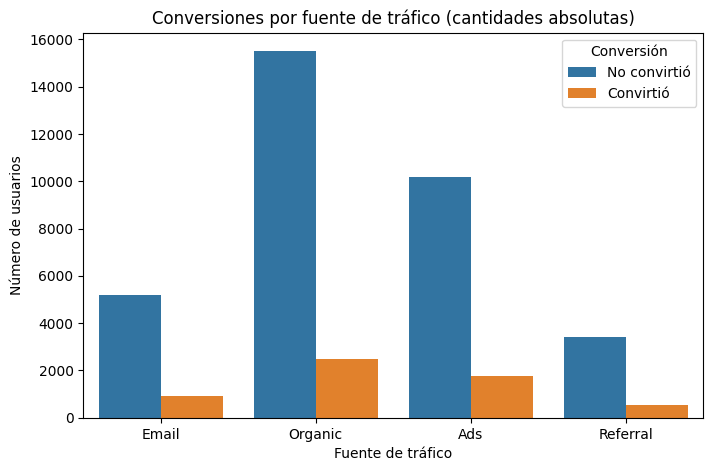

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='traffic_source', hue='converted')
plt.title('Conversiones por fuente de tráfico (cantidades absolutas)')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Número de usuarios')
plt.legend(title='Conversión', labels=['No convirtió', 'Convirtió'])
plt.show()

El gráfico muestra que Organic concentra el mayor volumen de usuarios,
seguido por Ads, Email y Referral. Esa diferencia de tamaño se traslada
a las conversiones absolutas: Organic genera la mayor cantidad de
conversiones del experimento pese a tener la tasa más baja. La lectura
en cantidades absolutas es la relevante para dimensionar el aporte de
cada canal al total de ingresos, pero no permite comparar su eficiencia.

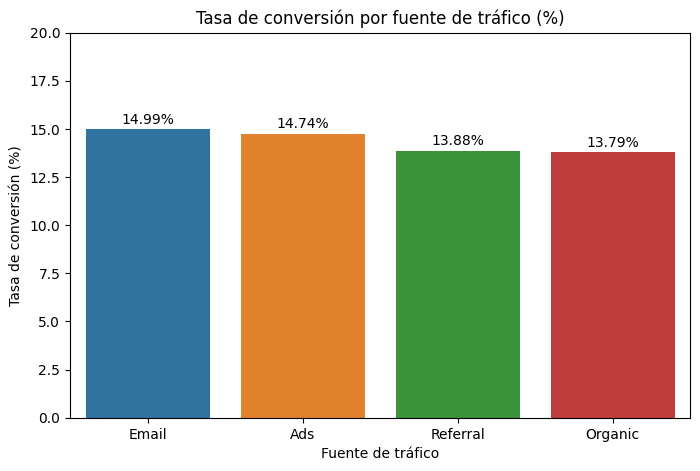

In [48]:

tasas_pct = (tasas[1] * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=tasas_pct.index, y=tasas_pct.values)
plt.title('Tasa de conversión por fuente de tráfico (%)')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Tasa de conversión (%)')
plt.ylim(0, 20)

for i, v in enumerate(tasas_pct.values):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.show()


Al comparar tasas en lugar de volúmenes, el orden se invierte: Email
(14.99%) y Ads (14.74%) superan a Referral (13.88%) y Organic (13.79%),
pese a que Organic era el canal con más usuarios. La escala del eje se
fijó de 0 a 20% para no exagerar visualmente una diferencia de apenas
1.20 puntos porcentuales entre el mejor y el peor canal, coherente con
el resultado de la prueba de chi-cuadrado.

En conjunto, ambos gráficos muestran que los canales pagados y directos
convierten mejor en proporción, mientras que Organic sostiene el mayor
aporte absoluto de conversiones por volumen de tráfico.

### Relación entre el tipo de usuario y la conversión

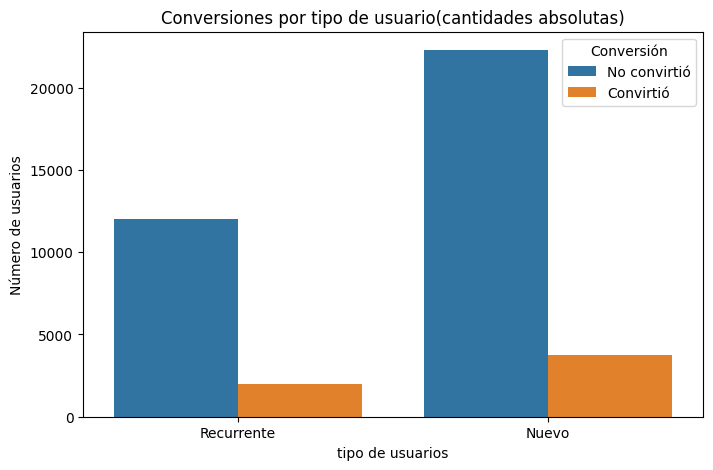

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversiones por tipo de usuario(cantidades absolutas)')
plt.xlabel('tipo de usuarios')
plt.ylabel('Número de usuarios')
plt.legend(title='Conversión', labels=['No convirtió', 'Convirtió'])
plt.show()

El gráfico muestra que los usuarios nuevos (26.033) representan
aproximadamente 1,9 veces la cantidad de usuarios recurrentes (13.967).
Esa diferencia de tamaño se refleja en las conversiones absolutas, que
son considerablemente mayores en el grupo de usuarios nuevos.

Sin embargo, la prueba de chi-cuadrado del Paso 5 (p = 0.4736) confirma
que ambos perfiles convierten en proporciones equivalentes: 14.36% los
nuevos y 14.09% los recurrentes, una diferencia de apenas 0.27 puntos
porcentuales. La mayor cantidad de conversiones en usuarios nuevos se
explica por el volumen del grupo, no por una mayor eficiencia.

Esto implica que el diseño de la página funciona de manera consistente
para ambos perfiles, por lo que no se requiere segmentar la
implementación ni desarrollar versiones diferenciadas por tipo de
usuario.

**Limitaciones:** no encontrar diferencia no significa que no exista;
implica que, de haberla, sería lo suficientemente pequeña como para que
este experimento no la distinga del azar. Además, el análisis evalúa el
tipo de usuario sobre el total del experimento, sin separar por versión
de página, por lo que no se descarta una interacción entre ambas
variables que el análisis agregado no captura.

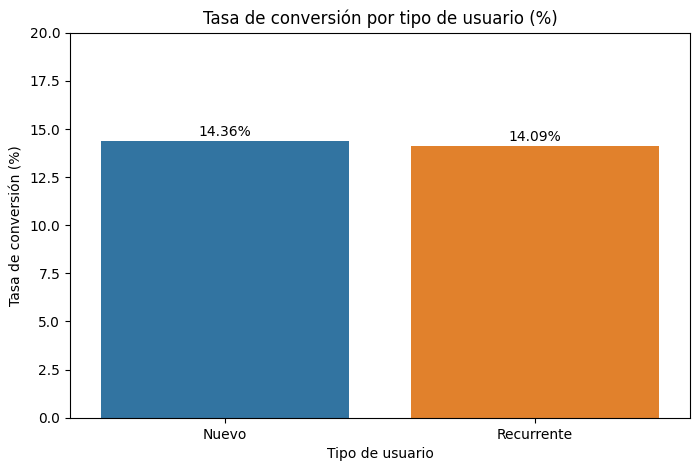

In [51]:
tasas2_pct = (tasas2[1] * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=tasas2_pct.index, y=tasas2_pct.values)
plt.title('Tasa de conversión por tipo de usuario (%)')
plt.xlabel('Tipo de usuario')
plt.ylabel('Tasa de conversión (%)')
plt.ylim(0, 20)

for i, v in enumerate(tasas2_pct.values):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.show()


Al comparar tasas en lugar de volúmenes, las diferencias observadas en
el gráfico anterior desaparecen: los usuarios nuevos convierten al
14.36% y los recurrentes al 14.09%, una diferencia de 0.27 puntos
porcentuales. La brecha visual del gráfico previo respondía únicamente
al mayor tamaño del grupo de usuarios nuevos, no a una mayor eficiencia.

La escala del eje se fijó de 0 a 20% para reflejar la diferencia en su
magnitud real, coherente con el resultado no significativo de la prueba
de chi-cuadrado del Paso 5 (p = 0.4736).

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Los usuarios que compraron en la página B gastaron en promedio 68.75, frente a 61.09 en la página A: 7.66 más por comprador.
- La diferencia representa un incremento del 12.5% en el ticket promedio y no se explica por variación aleatoria.
- **Interpretación:** la página B no solo atrae compras, sino compras de mayor valor. Cada cliente que convierte en B deja más dinero que uno que convierte en A, lo que amplifica el retorno de cualquier mejora en la tasa de conversión.

<br>

**Tasa de conversión:**
- La página B convirtió al 15.96% de sus visitantes frente al 12.57% de la página A: 3.38 puntos porcentuales más.
- En términos relativos, B convierte un 26.9% más que A, una diferencia demasiado consistente para atribuirse al azar.
- **Interpretación:** combinando ambos resultados, cada usuario que llega a la página B genera en promedio 10.97 de ingreso frente a 7.68 en la A, un 43% más. La ventaja de B no proviene de un solo factor: convierte a más visitantes y cada uno gasta más.

---

#### 📊 **Segmentación por fuente de tráfico**
- Email (14.99%) y Ads (14.74%) convierten por encima de Referral (13.88%) y Organic (13.79%), pero la brecha entre el mejor y el peor canal es de apenas 1.20 puntos porcentuales. Organic tiene la tasa más baja y a la vez concentra el mayor volumen de tráfico, por lo que aporta la mayor cantidad absoluta de conversiones.
- **Interpretación:** el canal influye en la conversión, pero mucho menos que la versión de la página. La diferencia entre canales es tres veces menor que la ganancia obtenida al cambiar de página, por lo que no justifica una reasignación agresiva de presupuesto. Reducir la inversión en Organic por su menor tasa sería contraproducente: es el canal que más conversiones totales genera.

 ---
#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos convierten al 14.36% y los recurrentes al 14.09%, una diferencia de 0.27 puntos porcentuales indistinguible del azar. La mayor cantidad de conversiones entre usuarios nuevos responde al tamaño del grupo, no a una mayor eficiencia.
- **Interpretación:** la página funciona de manera equivalente para ambos perfiles. No se requiere segmentar la implementación ni mantener versiones diferenciadas, lo que simplifica el despliegue y reduce costos de mantenimiento.
---
Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.
---
#### 💡 **Recomendaciones de negocio:**
- **Implementar la página B para el total del tráfico.** Supera a la A en los dos componentes del ingreso —convierte 26.9% más y genera un ticket 12.5% mayor—, lo que se traduce en aproximadamente 43% más de ingreso por usuario expuesto. El despliegue puede ser uniforme, ya que el efecto es consistente entre usuarios nuevos y recurrentes.
- **Mantener la distribución actual de inversión por canal.** Las diferencias de conversión entre canales son marginales (1.20 p.p.) y no sostienen una reasignación de presupuesto. Cualquier decisión sobre canales debería basarse en costo de adquisición, dato que este experimento no midió.
- **Validar el resultado antes del despliegue definitivo.** El análisis no contempla el costo de implementar la página B ni posibles efectos de novedad. Se recomienda monitorear la conversión y el gasto durante las primeras semanas posteriores al cambio, y evaluar en una siguiente fase la interacción entre versión de página y tipo de usuario.